In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [6]:
from sklearn.preprocessing import MinMaxScaler

In [7]:
%matplotlib inline

In [8]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/raw/Video_Games_Sales_as_at_22_Dec_2016.csv")

In [9]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.dtypes # check data types

Name                object
Platform            object
Year_of_Release    float64
Genre               object
Publisher           object
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score          object
User_Count         float64
Developer           object
Rating              object
dtype: object

In [11]:
df = df.drop(['User_Count','Critic_Count','Rating','User_Score'], axis=1) # remove columns

In [12]:
df = df.rename(columns={"Name": "Game Title", "Platform": "Console",
                        "Critic_Score": "Critic Score",
                        "Global_Sales": "Sales", "NA_Sales": "North American Sales",
                        "JP_Sales": "Japanese Sales", "EU_Sales": "EU Sales", 
                        "Other_Sales": "Other Sales", "Year_of_Release": "Release Year",})  # rename columns

In [13]:
df.head()

,Game Title,Console,Release Year,Genre,Publisher,North American Sales,EU Sales,Japanese Sales,Other Sales,Sales,Critic Score,Developer
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,Nintendo
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,Nintendo
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,Nintendo
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN


In [14]:
df.shape # check dimentions

(16719, 12)

In [15]:
df.count() # count rows

Game Title              16717
Console                 16719
Release Year            16450
Genre                   16717
Publisher               16665
North American Sales    16719
EU Sales                16719
Japanese Sales          16719
Other Sales             16719
Sales                   16719
Critic Score             8137
Developer               10096
dtype: int64

In [16]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)   #check duplicates 

number of duplicate rows:  (0, 12)


In [17]:
print(df.isnull().sum()) # missing values ( null )

Game Title                 2
Console                    0
Release Year             269
Genre                      2
Publisher                 54
North American Sales       0
EU Sales                   0
Japanese Sales             0
Other Sales                0
Sales                      0
Critic Score            8582
Developer               6623
dtype: int64


In [18]:
# 1. Drop rows with missing target
df = df.dropna(subset=['Sales'])

# 1. Drop rows with missing Names
df = df.dropna(subset=['Game Title'])

# 2. Fill categorical with "Unknown"
for col in ['Publisher','Developer','Genre','Console']:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# 3. Fill regional sales with 0
for col in ['North American Sales','Japanese Sales','EU Sales','Other Sales']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 4. Critic Score -> fill with mean
if 'Critic Score' in df.columns:
    df['Critic Score'] = df['Critic Score'].fillna(df['Critic Score'].mean()) 

# 5. Release Year -> fill with median
if 'Release Year' in df.columns:
    df['Release Year'] = df['Release Year'].fillna(df['Release Year'].median())    

In [19]:
df.head()

,Game Title,Console,Release Year,Genre,Publisher,North American Sales,EU Sales,Japanese Sales,Other Sales,Sales,Critic Score,Developer
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.000000,Nintendo
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,68.967679,Unknown
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.000000,Nintendo
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.000000,Nintendo
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,68.967679,Unknown


In [20]:
print(df.isnull().sum()) # missing values ( null )

Game Title              0
Console                 0
Release Year            0
Genre                   0
Publisher               0
North American Sales    0
EU Sales                0
Japanese Sales          0
Other Sales             0
Sales                   0
Critic Score            0
Developer               0
dtype: int64


In [21]:
df.count() # count rows

Game Title              16717
Console                 16717
Release Year            16717
Genre                   16717
Publisher               16717
North American Sales    16717
EU Sales                16717
Japanese Sales          16717
Other Sales             16717
Sales                   16717
Critic Score            16717
Developer               16717
dtype: int64

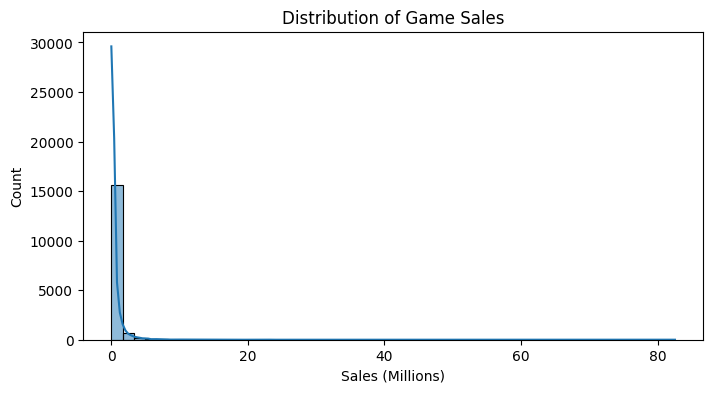

In [22]:
# Histogram for Game Sales Distribution 

plt.figure(figsize=(8,4))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title("Distribution of Game Sales")
plt.xlabel("Sales (Millions)")
plt.ylabel("Count")
plt.show()

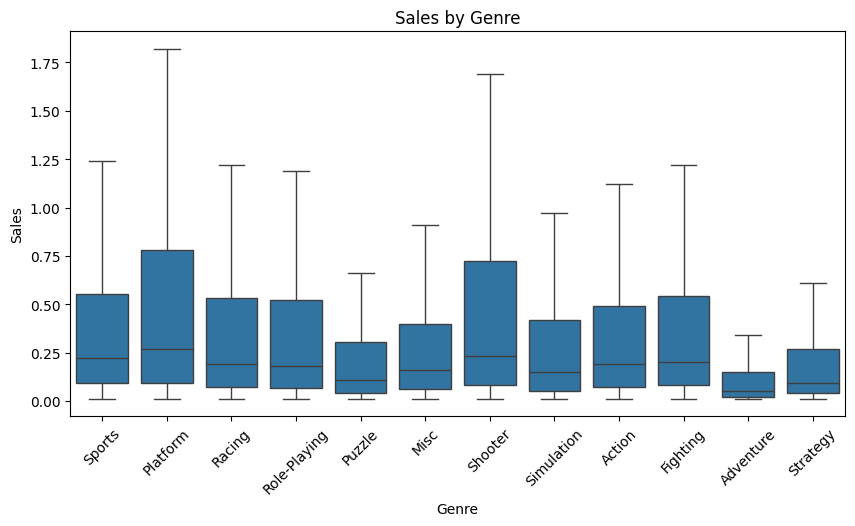

In [23]:
# Boxplot for Sales by Genre

plt.figure(figsize=(10,5))
sns.boxplot(x='Genre', y='Sales', data=df, showfliers=False)
plt.xticks(rotation=45)
plt.title("Sales by Genre")
plt.show()

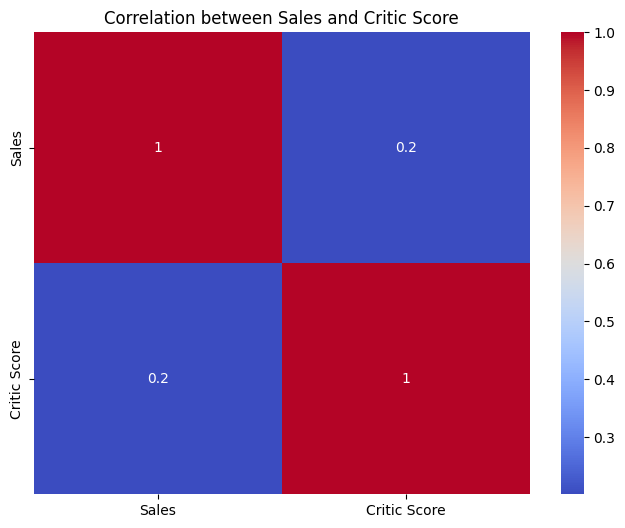

In [24]:
# Heatmap between Sales and Critic Score 
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Critic Score']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Sales and Critic Score")
plt.show()

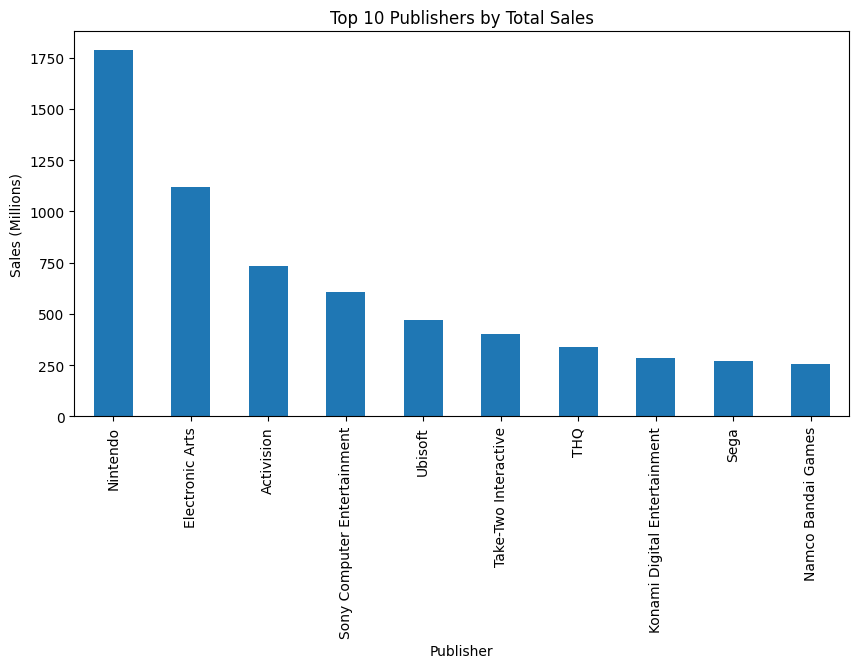

In [25]:
#Barplot for top 10 Publishers by Sales
top_publishers = df.groupby('Publisher')['Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_publishers.plot(kind='bar')
plt.title("Top 10 Publishers by Total Sales")
plt.ylabel("Sales (Millions)")
plt.show()

In [26]:
# Top publisher = Good Sales
top_publishers = ['Nintendo', 'Electronic Arts', 'Activision', 'Sony Computer Entertainment', 'Ubisoft','Take-Two Interactive']

df['Big Publisher'] = df['Publisher'].apply(lambda x: 1 if x in top_publishers else 0)

In [27]:
# One-hot encode Genre & Platform
df = pd.get_dummies(df, columns=['Genre','Console'], drop_first=True)

# For Publisher/Developer, keep top 30 and label others as "Other"
def cap_top(series, n=30):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), "Other")

df['Publisher'] = cap_top(df['Publisher'])
df['Developer'] = cap_top(df['Developer'])

# One-hot encode after capping
df = pd.get_dummies(df, columns=['Publisher','Developer'], drop_first=True)

In [28]:
df.head()

,Game Title,Release Year,North American Sales,EU Sales,Japanese Sales,Other Sales,Sales,Critic Score,Big Publisher,Genre_Adventure,...,Developer_Square Enix,Developer_THQ,Developer_TT Games,Developer_Traveller's Tales,Developer_Ubisoft,Developer_Ubisoft Montreal,Developer_Unknown,Developer_Vicarious Visions,Developer_Visual Concepts,Developer_Yuke's
0,Wii Sports,2006.0,41.36,28.96,3.77,8.45,82.53,76.000000,1,False,...,False,False,False,False,False,False,False,False,False,False
1,Super Mario Bros.,1985.0,29.08,3.58,6.81,0.77,40.24,68.967679,1,False,...,False,False,False,False,False,False,True,False,False,False
2,Mario Kart Wii,2008.0,15.68,12.76,3.79,3.29,35.52,82.000000,1,False,...,False,False,False,False,False,False,False,False,False,False
3,Wii Sports Resort,2009.0,15.61,10.93,3.28,2.95,32.77,80.000000,1,False,...,False,False,False,False,False,False,False,False,False,False
4,Pokemon Red/Pokemon Blue,1996.0,11.27,8.89,10.22,1.00,31.37,68.967679,1,False,...,False,False,False,False,False,False,True,False,False,False


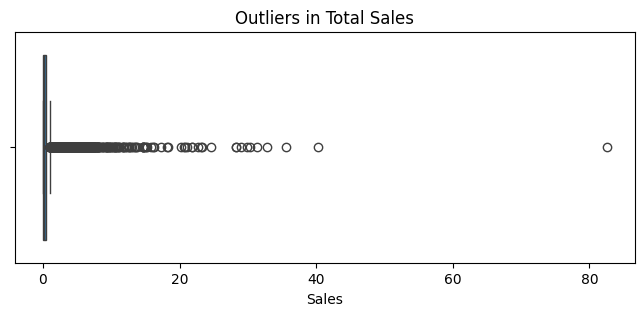

In [29]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['Sales'])
plt.title("Outliers in Total Sales")
plt.show()

In [30]:
# Scale Critic Score between 0-1 ( Normalization )
scaler = MinMaxScaler()

# Scale critic score only (keep Sales as original for prediction target)
df['Critic Score'] = scaler.fit_transform(df[['Critic Score']])

In [31]:
df.head()

,Game Title,Release Year,North American Sales,EU Sales,Japanese Sales,Other Sales,Sales,Critic Score,Big Publisher,Genre_Adventure,...,Developer_Square Enix,Developer_THQ,Developer_TT Games,Developer_Traveller's Tales,Developer_Ubisoft,Developer_Ubisoft Montreal,Developer_Unknown,Developer_Vicarious Visions,Developer_Visual Concepts,Developer_Yuke's
0,Wii Sports,2006.0,41.36,28.96,3.77,8.45,82.53,0.741176,1,False,...,False,False,False,False,False,False,False,False,False,False
1,Super Mario Bros.,1985.0,29.08,3.58,6.81,0.77,40.24,0.658443,1,False,...,False,False,False,False,False,False,True,False,False,False
2,Mario Kart Wii,2008.0,15.68,12.76,3.79,3.29,35.52,0.811765,1,False,...,False,False,False,False,False,False,False,False,False,False
3,Wii Sports Resort,2009.0,15.61,10.93,3.28,2.95,32.77,0.788235,1,False,...,False,False,False,False,False,False,False,False,False,False
4,Pokemon Red/Pokemon Blue,1996.0,11.27,8.89,10.22,1.00,31.37,0.658443,1,False,...,False,False,False,False,False,False,True,False,False,False


In [32]:
# Scale Sales & Regional Sales between 0-1 
# Define the sales columns 
sales_cols = ['Sales', 'North American Sales', 'EU Sales', 'Japanese Sales', 'Other Sales']

scaler = MinMaxScaler()

# Fit + transform the sales columns
df[sales_cols] = scaler.fit_transform(df[sales_cols])

In [33]:
# Create decade column
df['Decade'] = (df['Release Year'] // 10) * 10

# Percentages of sales per region 
df['NA Share'] = df['North American Sales'] / df['Sales']
df['EU Share'] = df['EU Sales'] / df['Sales']
df['JP Share'] = df['Japanese Sales'] / df['Sales']
df['Other Share'] = df['Other Sales'] / df['Sales']

# New Game ?
df['Is Recent'] = df['Release Year'].apply(lambda x: 1 if x >= 2010 else 0)

In [34]:
df.head()

,Game Title,Release Year,North American Sales,EU Sales,Japanese Sales,Other Sales,Sales,Critic Score,Big Publisher,Genre_Adventure,...,Developer_Unknown,Developer_Vicarious Visions,Developer_Visual Concepts,Developer_Yuke's,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent
0,Wii Sports,2006.0,1.000000,1.000000,0.368885,0.799432,1.000000,0.741176,1,False,...,False,False,False,False,2000.0,1.000000,1.000000,0.368885,0.799432,0
1,Super Mario Bros.,1985.0,0.703095,0.123619,0.666341,0.072848,0.487518,0.658443,1,False,...,True,False,False,False,1980.0,1.442192,0.253568,1.366801,0.149426,0
2,Mario Kart Wii,2008.0,0.379110,0.440608,0.370841,0.311258,0.430320,0.811765,1,False,...,False,False,False,False,2000.0,0.880996,1.023907,0.861781,0.723318,0
3,Wii Sports Resort,2009.0,0.377418,0.377417,0.320939,0.279092,0.396995,0.788235,1,False,...,False,False,False,False,2000.0,0.950687,0.950686,0.808422,0.703011,0
4,Pokemon Red/Pokemon Blue,1996.0,0.272485,0.306975,1.000000,0.094607,0.380029,0.658443,1,False,...,True,False,False,False,1990.0,0.717012,0.807767,2.631378,0.248948,0


In [35]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/cleaned/VG_Chartz_2016_Cleaned.csv", index=False)